In [1]:
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-03-15 03:25:52--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-03-15 03:25:52--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-03-15 03:25:52--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... conne

In [2]:
import numpy as np
fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

In [3]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)

KMeans(n_clusters=3, random_state=42)

In [4]:
print(km.labels_)

[2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 0 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]


In [6]:
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


In [7]:
import matplotlib.pyplot as plt
def draw_fruits(arr, ratio=1):
  n = len(arr) # n은 샘플 개수
  # 한 줄에 10개씩 이미지를 그린다. 샘플 개수를 10으로 나누어 전체 행 개수를 계산한다.
  rows = int(np.ceil(n/10))
  # 행이 1개이면 열의 개수는 샘플 개수이다. 그렇지 않으면 10개이다.
  cols = n if rows < 2 else 10
  fig, axs = plt.subplots(rows, cols, figsize=(cols*ratio, rows*ratio), squeeze=False)

  for i in range(rows):
    for j in range(cols):
        if i*10 + j < n:
            axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
        axs[i, j].axis('off')
  plt.show()

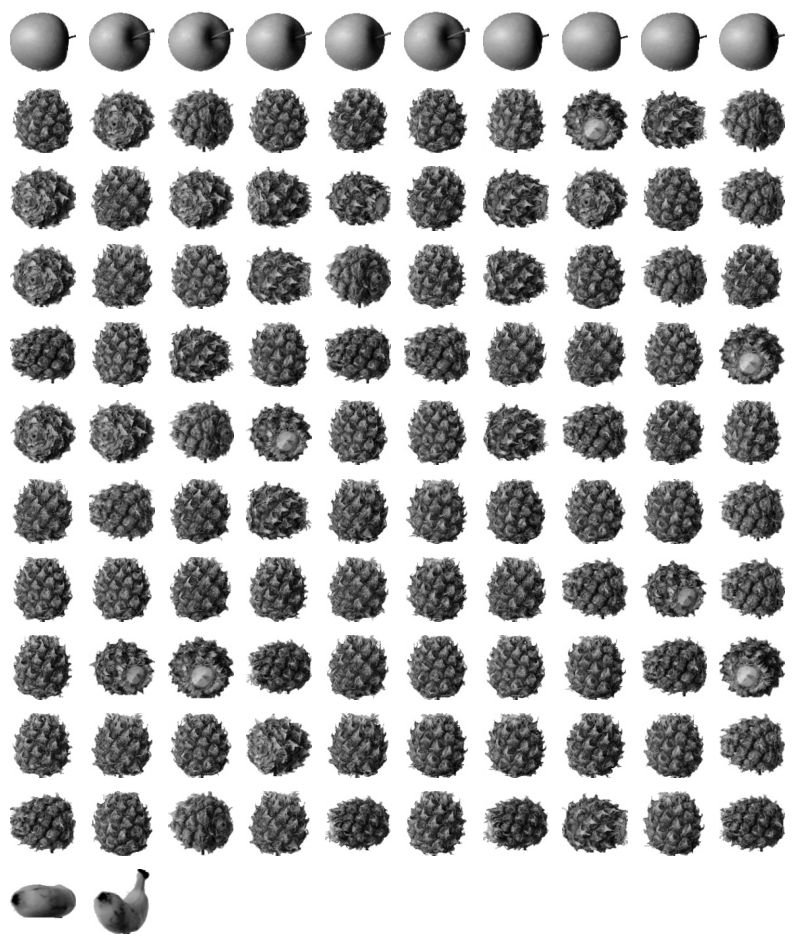

In [11]:
draw_fruits(fruits[km.labels_==0])

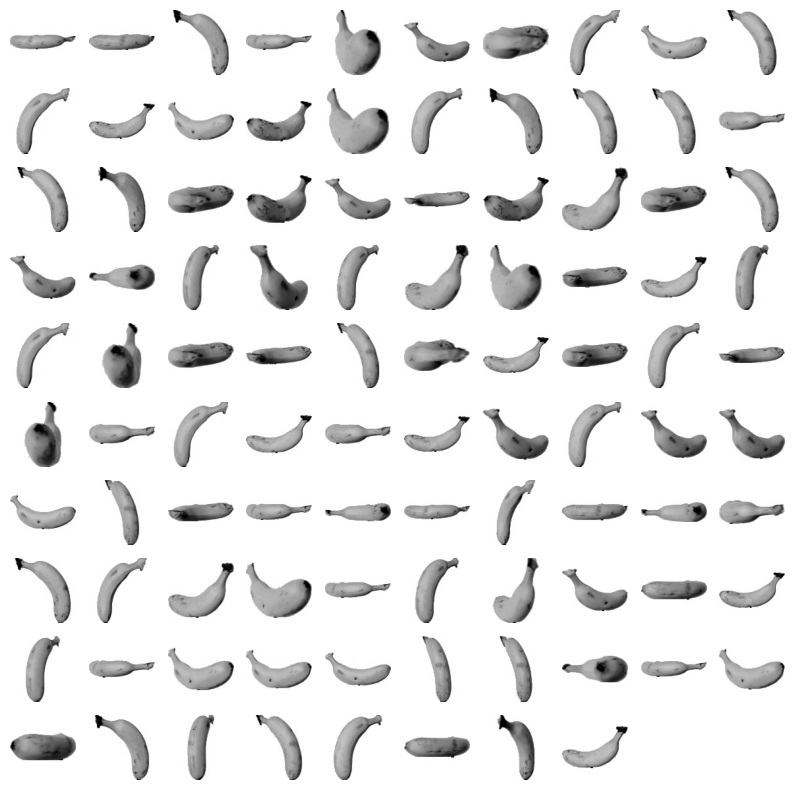

In [12]:
draw_fruits(fruits[km.labels_==1])

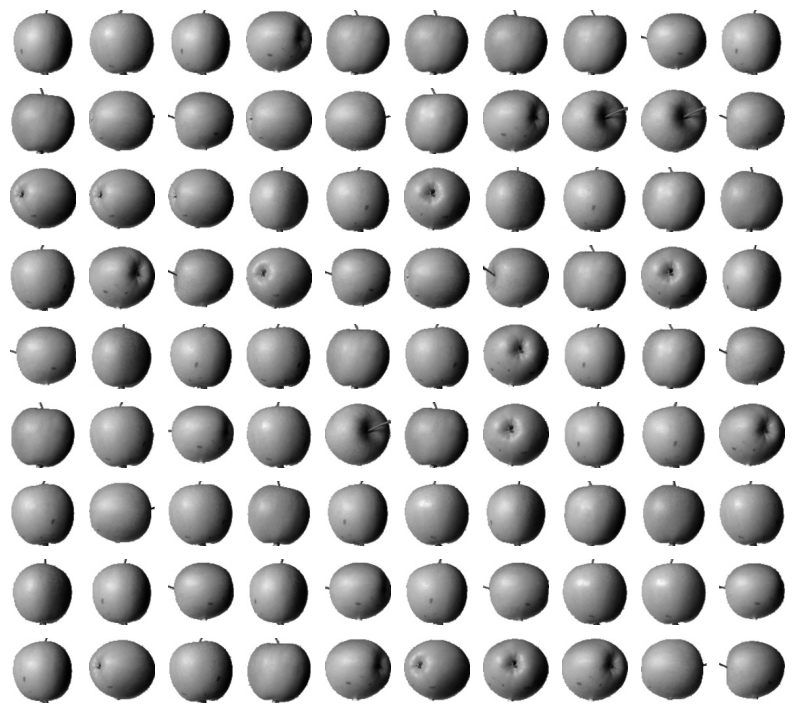

In [13]:
draw_fruits(fruits[km.labels_==2])

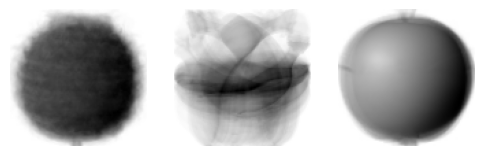

In [21]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=2)

In [22]:
print(km.transform(fruits_2d[100:101]))

[[3400.24197319 8837.37750892 5279.33763699]]


In [23]:
print(km.predict(fruits_2d[100:101]))

[0]


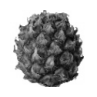

In [25]:
draw_fruits(fruits[100:101])

In [26]:
print(km.n_iter_)

4


In [28]:
print(fruits_2d[100:101].shape)

(1, 10000)


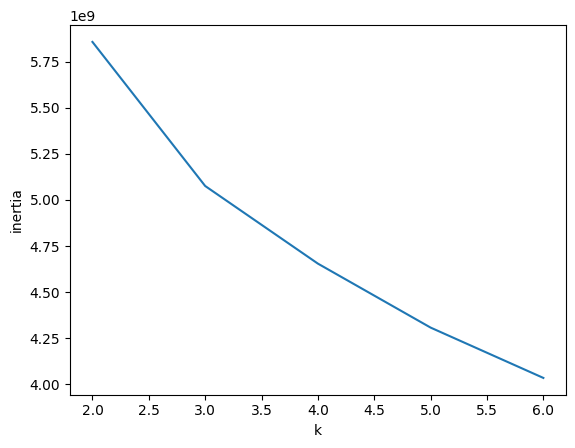

In [30]:
inertia = []
for k in range(2, 7):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(fruits_2d)
  inertia.append(km.inertia_)
plt.plot(range(2, 7), inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

In [66]:
# Q. K-평균 알고리즘은 입력된 데이터셋에서 같은 종류의 샘플들이 모여있으면 큰 효과를 발휘할 것으로 보인다.
# 그런데 만약에 입력된 데이터들이 비슷한 종류끼리 모여있지 않고, 무작위로 샘플들이 흩어져있으면 어떻게 될까?
# 예를 들어, 현재 사용한 fruits 데이터는 사과, 파인애플, 바나나가 같은 종류끼리 묶여있다. 그러나 300개의 샘플이 무작위로 섞여있는 경우에는 K-평균 알고리즘이 잘 작동하는 것일까?

In [67]:
# 확인을 위해 주어진 샘플의 순서를 무작위로 섞어보았다.

fruits_shuffled = np.random.permutation(fruits)
print(fruits_shuffled.shape)

(300, 100, 100)


In [57]:
# KMeans 모델 학습을 위해 데이터를 300 * 10000 으로 변환한다.

fruits_shuffled_2d = fruits_shuffled.reshape(-1, 100*100)

In [58]:
# km_shuf 객체에 모델을 학습한다.

from sklearn.cluster import KMeans
km_shuf = KMeans(n_clusters=3, random_state=42)
km_shuf.fit(fruits_shuffled_2d)

KMeans(n_clusters=3, random_state=42)

In [59]:
# 알고리즘이 분류한 결과를 출력한다. 잘 섞인 것을 확인할 수 있다.

print(km_shuf.labels_)

[0 0 2 0 1 1 1 1 1 0 2 2 1 2 1 2 0 1 0 1 2 1 1 2 0 2 2 0 2 0 0 0 2 2 0 1 0
 1 0 2 1 0 2 2 2 1 2 2 2 2 0 2 1 1 1 1 1 2 0 1 0 0 1 0 1 0 0 0 2 1 2 0 0 0
 1 1 1 0 1 0 0 1 1 2 0 2 2 2 2 0 1 0 0 1 1 1 2 2 2 1 0 1 0 0 2 0 1 0 0 1 0
 0 0 0 1 2 2 2 0 1 0 1 0 0 0 1 1 1 0 1 2 0 2 2 2 2 2 2 1 2 2 2 2 0 1 0 2 0
 0 2 2 0 2 1 0 1 2 2 0 1 2 1 2 0 2 2 2 2 2 2 0 2 1 1 0 2 2 0 0 1 1 2 0 2 2
 0 2 2 0 1 0 1 1 1 1 2 0 2 0 0 2 2 0 1 1 1 0 2 2 0 0 0 1 1 2 0 1 0 2 0 2 2
 0 1 1 2 1 1 1 1 2 0 1 2 1 1 1 1 1 0 1 2 1 0 0 1 2 2 2 2 1 2 0 0 0 2 0 0 2
 2 1 0 0 2 0 0 2 2 2 0 2 0 0 2 1 2 0 2 1 2 2 0 2 0 2 2 2 2 2 1 0 1 2 2 1 1
 1 0 1 2]


In [61]:
# 비슷하게 100개씩 분류하고, 하나는 110개로 분류하여 오류가 조금 있다.

print(np.unique(km_shuf.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([ 99,  91, 110]))


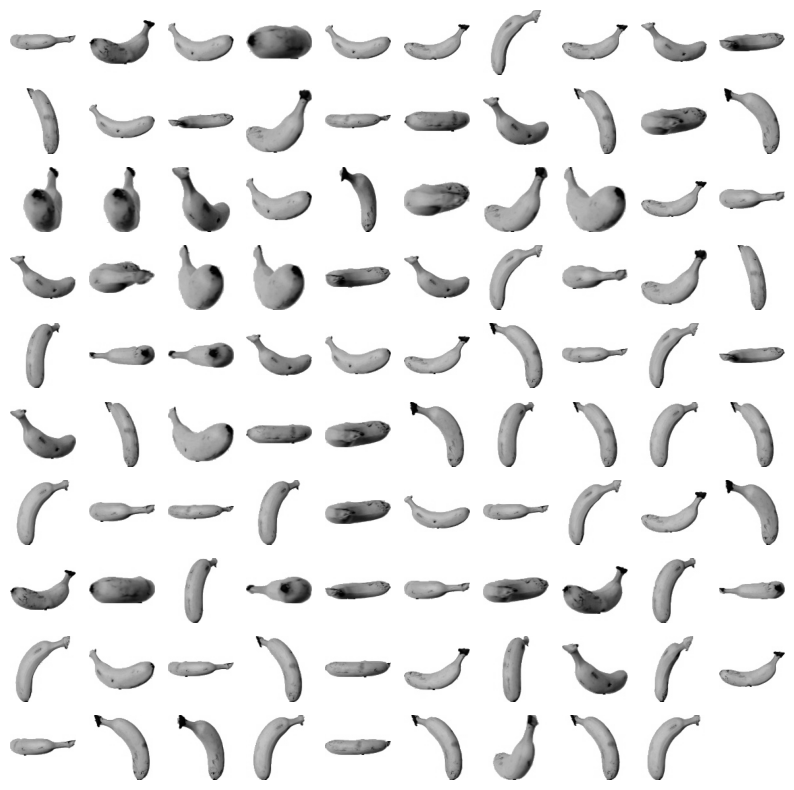

In [63]:
# 0, 1, 2에 해당하는 그림을 그려보았다.

draw_fruits(fruits_shuffled[km_shuf.labels_==0])

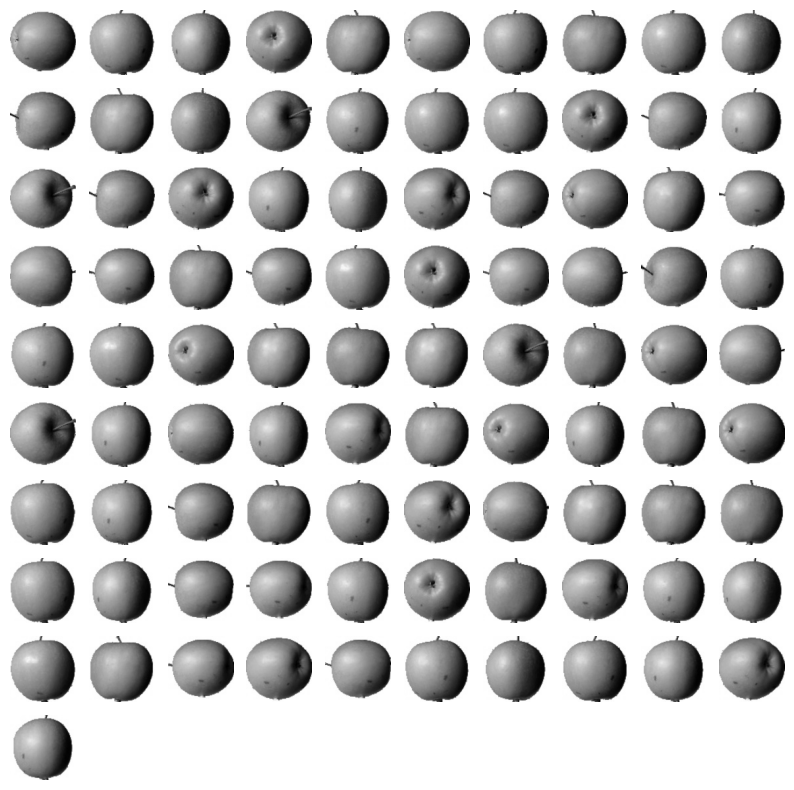

In [64]:
draw_fruits(fruits_shuffled[km_shuf.labels_==1])

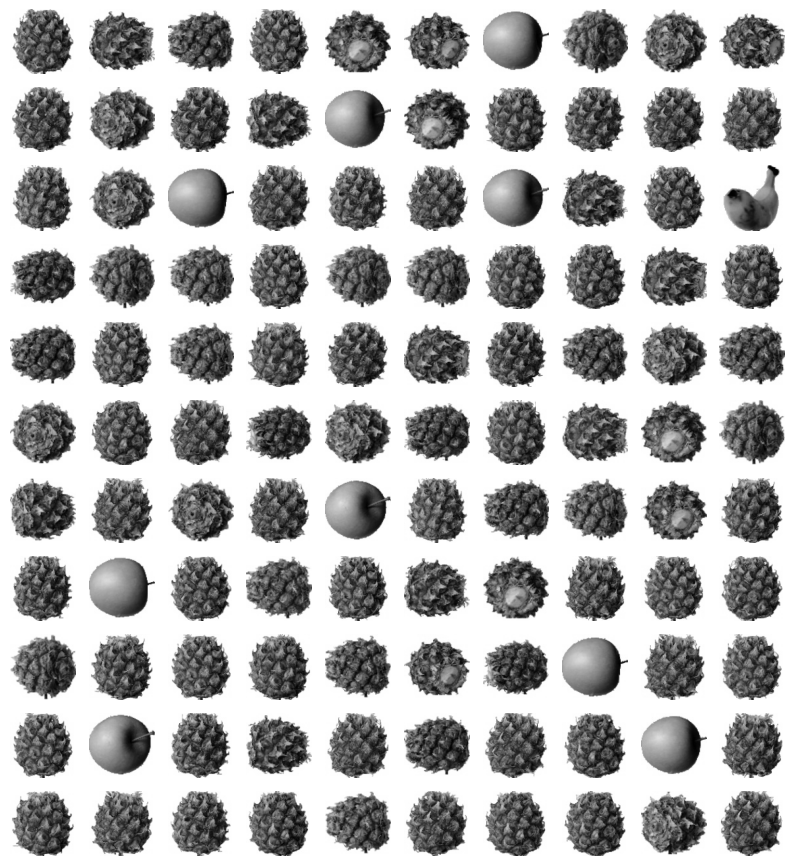

In [65]:
# 아까와 같이 파인애플만 초과 분류한 것을 확인할 수 있다.

draw_fruits(fruits_shuffled[km_shuf.labels_==2])

In [ ]:
# 실험 결과: 내 예상은 K-군집 알고리즘을 사용할 때 데이터가 무작위로 흩어져있으면 같은 종류끼리 묶는 것이 힘들 거라고 생각했다.
# 그러나 결과는 정반대로 알고리즘이 잘 작동하는 것을 확인했다. 이유가 뭘까?

# K-군집 알고리즘이 입력받는 100*100 데이터(이미지)는 10000차원 공간에 찍힌 하나의 점일 뿐이다. 즉, 300개의 점이 10000차원 공간에 찍혀있는 셈이다.
# 300 * 100 * 100 데이터에서 300개의 샘플을 섞는다는 뜻은, 10000차원 공간에 점을 찍는 '순서'만 바꾸는 뜻이다.
# 10000차원 공간에 사과라는 점들은 비슷한 위치에 모여있고, 바나나와 파인애플도 마찬가지다.
# 사과를 모두 찍고 바나나를 모두 찍고, 파인애플을 모두 찍는 것과 사과, 바나나, 파인애플을 무작위로 섞어서 찍는 것은 결과적으로 점들의 배치에 아무런 영향을 주지 않는다.
# 즉, 300개의 샘플을 섞는다는 것은 '점을 찍는 순서'만 바꾸는 것이지, 실제 이미지 데이터(100 * 100)을 바꾸는 것이 아니다.

# 결론.
# K-군집 알고리즘은 공간상에 찍힌 점들의 결과만 보고 비슷한 군집끼리 묶는 것이므로, 샘플의 입력 순서를 바꾸더라도 결과에 큰 영향을 주지 않는다.